## Cross Validation

### Learning objectives

By the end of this lesson, you will be able to:

* Chain multiple data processing steps together using `Pipeline`
* Use the `KFolds` object to split data into multiple folds.
* Perform cross validation using SciKit Learn with `cross_val_predict` and `GridSearchCV`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [2]:
# datapath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/boston_housing_clean.pickle"

boston = pd.read_pickle("data/boston_housing_clean.pickle")
boston.keys()

boston_data = boston['dataframe']
boston_desc = boston['description']

boston_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### Thoughts 1

Suppose we want to do Linear Regression on our dataset to get an estimate, based on mean squared error, of how well our model will perform on data outside our dataset. 

Suppose also that our data is split into three folds: Fold 1, Fold 2, and Fold 3.

What would the steps be to do this?

In [3]:
X = boston_data.drop('MEDV', axis=1)
y = boston_data.MEDV

# setting up the folds
kf = KFold(shuffle=True, random_state=72018, n_splits=3)
for train_index, test_index in kf.split(X):
    print("Train index:", train_index[:10], len(train_index))
    print("Test index:",test_index[:10], len(test_index))
    print('')

Train index: [ 1  3  4  5  7  8 10 11 12 13] 337
Test index: [ 0  2  6  9 15 17 19 23 25 26] 169

Train index: [ 0  2  6  9 10 11 12 13 15 17] 337
Test index: [ 1  3  4  5  7  8 14 16 22 27] 169

Train index: [0 1 2 3 4 5 6 7 8 9] 338
Test index: [10 11 12 13 18 20 21 24 28 31] 168



Train and Score the Cross Validation data

In [4]:
scores = []
lr = LinearRegression()

for train_index, test_index in kf.split(X):
    X_train, X_test, y_train, y_test = (X.iloc[train_index, :], X.iloc[test_index, :], y[train_index], y[test_index])
    
    lr.fit(X_train, y_train)
        
    y_pred = lr.predict(X_test)

    score = r2_score(y_test.values, y_pred)
    
    scores.append(score)
    
scores

[0.6719348798472751, 0.7485020059212362, 0.697680732359776]

That's a bit cumbersome, but do-able.

<BR>

### Thoughts 2

Now suppose we want to do the same, but appropriately scaling our data as we go through the folds.

What would the steps be _now_?

In [5]:
scores = []

lr = LinearRegression()
s = StandardScaler()

for train_index, test_index in kf.split(X):
    X_train, X_test, y_train, y_test = (X.iloc[train_index, :], X.iloc[test_index, :], y[train_index], y[test_index])
    
    X_train_s = s.fit_transform(X_train)
    
    lr.fit(X_train_s, y_train)
    
    X_test_s = s.transform(X_test)
    
    y_pred = lr.predict(X_test_s)

    score = r2_score(y_test.values, y_pred)
    
    scores.append(score)


scores

[0.6719348798472713, 0.748502005921238, 0.6976807323597745]

(same scores, because for vanilla linear regression with no regularization, scaling actually doesn't matter for performance)

This is getting quite cumbersome!

Luckily, SciKit Learn has some wonderful functions that handle a lot of this for us.


#### **Pipeline and cross_val_predict**

Pipeline lets you chain together multiple operators on your data as long as they have a fit method.

<u>Combine multiple processing steps into a Pipeline</u>

A pipeline contains a series of steps, where a step is ("name of step", actual_model). The "name of step" string is only used to help you identify which step you are on, and to allow you to specify parameters at that step. 

In [6]:
s = StandardScaler()
lr = LinearRegression()

estimator = Pipeline([("scaler", s), ("regression", lr)])

#### `cross_val_predict`

[`cross_val_predict`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html) is a function that does K-fold cross validation for us, appropriately fitting and transforming at every step of the way.

In [7]:
print(kf)
predictions = cross_val_predict(estimator, X, y, cv=kf)

print(f"\nr2_score (cross_val_predict)      : {r2_score(y, predictions)}")
print(f"r2_score (mean of previous scores): {np.mean(scores)}") # almost identical

KFold(n_splits=3, random_state=72018, shuffle=True)

r2_score (cross_val_predict)      : 0.706353106416156
r2_score (mean of previous scores): 0.7060392060427612


Note that `cross_val_predict` doesn't use the same model for all steps; the predictions for each row are made when that row is in the validation set. We really have the collected results of 3 (i.e. `kf.num_splits`) different models. 

When we are done, `estimator` is still not fitted. If we want to predict on _new_ data, we still have to train our `estimator`. 

<BR>

### Hyperparameter tuning

**Definition**
>> Hyperparameters are the parts where we tuned ourself, whereas parameters are learned by the model using machine learning. **Hyperparameter tuning** involves using cross validation (or train-test split) to determine which hyperparameters are most likely to generate a model that **_generalizes_** well outside of your sample.

<BR>

**Mechanics**
>> We can generate an exponentially spaces range of values using the numpy [`geomspace`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.geomspace.html#numpy.geomspace) function.

```python
    np.geomspace(1, 1000, num=4)
```

>> produces:
```python
    array([    1.,    10.,   100.,  1000.])
```


>> Use this function to generate a list of length 10 called `alphas` for hyperparameter tuning, for example:

In [8]:
alphas = np.geomspace(1e-9, 1e0, num=10)
alphas

array([1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02,
       1.e-01, 1.e+00])

The code below tunes the `alpha` hyperparameter for Lasso regression.

In [9]:
scores = []
coefs = []
for alpha in alphas:
    las = Lasso(alpha=alpha, max_iter=100000)
    
    estimator = Pipeline([ ("scaler", s), ("lasso_regression", las) ])

    predictions = cross_val_predict(estimator, X, y, cv = kf)
    
    score = r2_score(y, predictions)
    
    scores.append(score)

In [10]:
list(zip(alphas,scores))

[(np.float64(1e-09), 0.7063531064981925),
 (np.float64(1e-08), 0.7063531072356071),
 (np.float64(1e-07), 0.7063531145602442),
 (np.float64(1e-06), 0.7063531882052065),
 (np.float64(1e-05), 0.7063539165191507),
 (np.float64(0.0001), 0.706361268093463),
 (np.float64(0.001), 0.7064334670415461),
 (np.float64(0.01), 0.7070865958083233),
 (np.float64(0.1), 0.705838151167185),
 (np.float64(1.0), 0.6512724532884886)]

Note that the alpha values has an inverse relationship with model complexity. The higher the alpha value, the lesser model complexity; and the lower the alpha, the higher the model complexity. We must alway scale the training data when using alphas.

In [11]:
# fitting with small alpha
Lasso(alpha=1e-6).fit(X, y).coef_

array([-1.07170372e-01,  4.63952623e-02,  2.08588308e-02,  2.68854318e+00,
       -1.77954207e+01,  3.80475296e+00,  7.50802707e-04, -1.47575348e+00,
        3.05654279e-01, -1.23293755e-02, -9.53459908e-01,  9.39253013e-03,
       -5.25467196e-01])

In [12]:
# fitting with high alpha
Lasso(alpha=1.0).fit(X, y).coef_

array([-0.06342255,  0.04916867, -0.        ,  0.        ,  0.        ,
        0.94678567,  0.02092737, -0.66900864,  0.26417501, -0.01520915,
       -0.72319901,  0.00829117, -0.76143296])

A zero value coefficient effectively remove the specific feature.

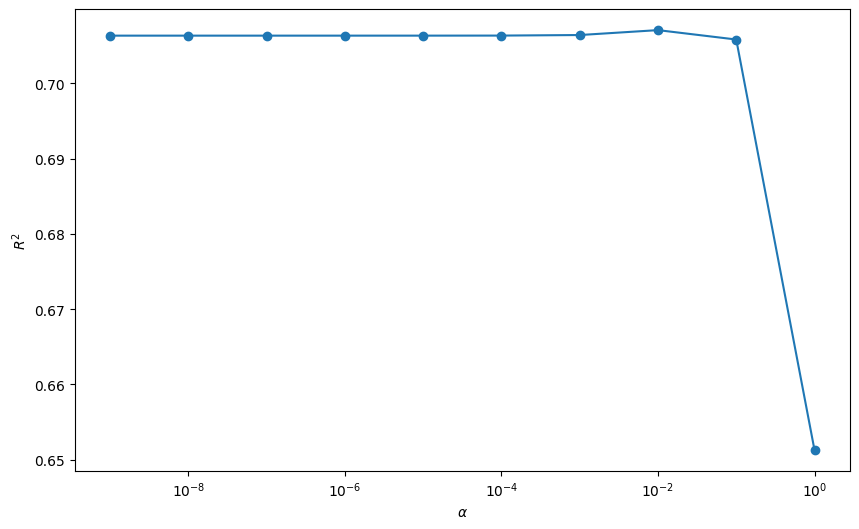

In [13]:
plt.figure(figsize=(10,6))
plt.semilogx(alphas, scores, '-o')
plt.xlabel('$\\alpha$')
plt.ylabel('$R^2$');

The above plot shows the trade-off between higher complexity and error rate. As shown it is faily level throughout. So we probably don't need so much regularization as we are just working with plain lasso model with just the standard scalar. When using more features, e.g. polynomial features, we will need to actually reduce the complexity, and probably move many of these actual interactive terms of squared values.

#### Exercise

Add `PolynomialFeatures` to this `Pipeline`, and re-run the cross validation with the `PolynomialFeatures` added.

**Hint #1:** pipelines process input from first to last. Think about the order that it would make sense to add Polynomial Features to the data in sequence and add them in the appropriate place in the pipeline. If you standardize first, you will end up with negative and positive values, and also will end up with much smaller scales. But if we scale it second, we will ensure each one will be on the same scale at the end. This can help to better see the interaction between the scaled data and the scores. Here we will do PolynomialFeatures first follow by scaling, which is generally regarded as best practice.

**Hint #2:** you should see a significant increase in cross validation accuracy from doing this

/home/samlau/Python/ML-Projects-and-tutorials/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.084e+01, tolerance: 2.735e+00
  model = cd_fast.enet_coordinate_descent(
/home/samlau/Python/ML-Projects-and-tutorials/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.343e+01, tolerance: 2.777e+00
  model = cd_fast.enet_coordinate_descent(
/home/samlau/Python/ML-Projects-and-tutorials/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of i

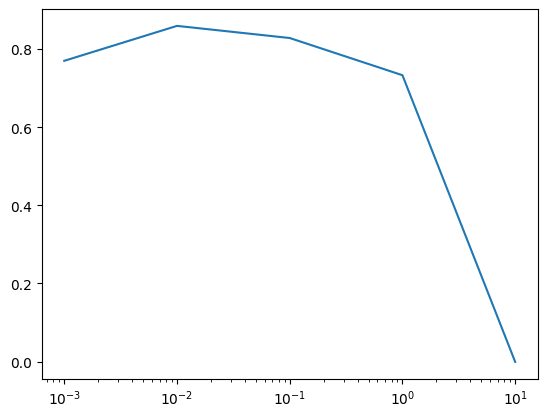

In [14]:
pf = PolynomialFeatures(degree=3)

scores = []
# alphas = np.geomspace(0.06, 6.0, 20)
alphas = np.geomspace(0.001, 10, 5)
for alpha in alphas:
    las = Lasso(alpha=alpha, max_iter=100000) # max_iter = max. iteration to get optimal values
    
    estimator = Pipeline([ ("make_higher_degree", pf), ("scaler", s), ("lasso_regression", las) ])

    predictions = cross_val_predict(estimator, X, y, cv=kf)
    
    score = r2_score(y, predictions)
    
    scores.append(score)


plt.semilogx(alphas, scores)

In [15]:
alphas

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01])

In [16]:
scores

[0.7697086980421521,
 0.8591002095361685,
 0.8280423631185617,
 0.7328688516176428,
 -0.000616160136140298]

Once we have found the hyperparameter (alpha~1e-2=0.01), make the model and train it on ALL the data.

In [17]:
# best_estimator = Pipeline([ ("scaler", s), ("make_higher_degree", PolynomialFeatures(degree=2)), ("lasso_regression", Lasso(alpha=0.03)) ])
best_estimator = Pipeline([ ("make_higher_degree", PolynomialFeatures(degree=2)), ("scaler", s), ("lasso_regression", Lasso(alpha=0.01, max_iter=10000)) ])
best_estimator.fit(X, y)
best_estimator.score(X, y)

0.9032551408154246

In [18]:
best_estimator.named_steps["lasso_regression"].coef_

array([ 0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        4.61127587e+00,  0.00000000e+00,  6.24240557e-01,  0.00000000e+00,
       -7.22878514e+00,  9.74968793e+00,  0.00000000e+00,  0.00000000e+00,
        6.34548325e-01,  0.00000000e+00,  9.95741679e-01, -5.51374291e-03,
       -0.00000000e+00,  2.44370838e+00, -2.40444044e+00, -0.00000000e+00,
       -0.00000000e+00, -2.23044443e-01, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -2.88128934e-01,  5.17203914e-01,  3.07715719e-01,
       -3.39853933e-01, -9.86590910e-02, -0.00000000e+00,  2.72847487e-01,
       -0.00000000e+00, -6.39829763e-01, -3.16474346e-01,  1.44555554e+00,
        0.00000000e+00, -0.00000000e+00, -8.84630187e-01,  1.32081558e+00,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  2.63148300e+00,
       -2.62941147e-01,  0.00000000e+00,  9.08410143e-01, -8.17144528e-01,
        0.00000000e+00, -4.31628234e+00,  5.53254405e-01, -2.91912598e+00,
       -4.68486241e+00,  

As shown in the coefficient list above, many of the features are zeroed out for our optimal score of 0.903255.

### Exercise

Do the same, but with `Ridge` regression 

Which model, `Ridge` or `Lasso`, performs best with its optimal hyperparameters on the Boston dataset?

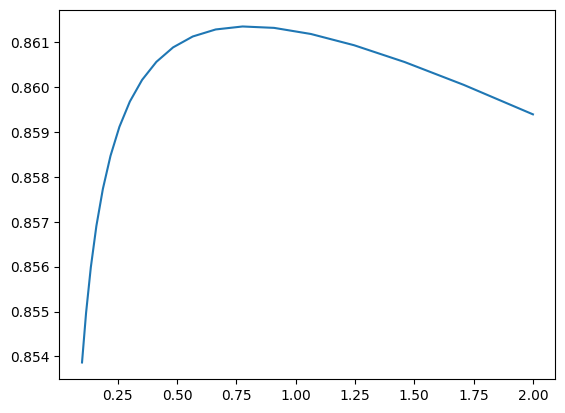

In [19]:
pf = PolynomialFeatures(degree=2)
# alphas = np.geomspace(4, 20, 20)
alphas = np.geomspace(0.1, 2, 20)
scores=[]
for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=100000)

    estimator = Pipeline([ ("polynomial_features", pf), ("scaler", s), ("ridge_regression", ridge) ])

    predictions = cross_val_predict(estimator, X, y, cv=kf)
    score = r2_score(y, predictions)

    scores.append(score)

plt.plot(alphas, scores)

In [20]:
alphas

array([0.1       , 0.11707799, 0.13707256, 0.1604818 , 0.18788887,
       0.21997651, 0.25754408, 0.30152744, 0.35302227, 0.41331138,
       0.48389667, 0.5665365 , 0.66328955, 0.77656608, 0.90918797,
       1.06445901, 1.24624723, 1.45908123, 1.70826299, 2.        ])

In [21]:
scores

[0.8538653466411248,
 0.8549696024101614,
 0.8559834219296792,
 0.8569037245063602,
 0.8577303577708401,
 0.8584654302624157,
 0.8591123985569579,
 0.8596750594632492,
 0.8601566057602492,
 0.8605588792364034,
 0.860881904614084,
 0.8611237246559511,
 0.8612804946727344,
 0.8613467465810996,
 0.8613157070191644,
 0.8611795534634974,
 0.8609295140801457,
 0.8605557549667363,
 0.8600470452272581,
 0.8593902395694215]

So from the above, when using the Ridge model, our optimal score value of 0.86135 is at alpha = 0.77657.

In [22]:
best_estimator = Pipeline([ ("make_higher_degree", PolynomialFeatures(degree=2)), ("scaler", s), ("ridge_regression", Ridge(alpha=0.77657, max_iter=100000)) ])
best_estimator.fit(X, y)
best_estimator.score(X, y)

0.9132985340816707

**Conclusion:** 

Our conclusion that we can get from ​from both of these curves having ​this upward trajectory and then this downward slope, ​is that using the alpha value ​in order to reduce complexity: ​no alpha value at ​all would be essentially the same as linear regression. ​So we can see that as we reduce complexity slightly, ​we're actually able to improve ​how well we are able to generalize our model. ​Reducing complexity even on a simple model ​such as linear regression is doing ​well in regards to optimizing ​how well we will perform on our holdout sets. 

Both Lasso and Ridge with proper hyperparameter tuning give better results than plain ol' Linear Regression!

#### Exercise:

So how do we look at what is important in feature selection. Now, for whatever your best overall hyperparameter was: 

* Standardize the data - ensure all the features are on the same scale to avoid its effect on the target median value.
* Fit and predict on the entire training dataset for interpretation purpose (in contrast to prediction purpose).
* See what the largest coefficients were

>> Use 
```python
        dict(zip(model.coef_, pf.get_feature_names()))
```
>> for your model `model` to get the feature names from `PolynomialFeatures`.
    
>> Then, use
```python
        dict(zip(list(range(len(X.columns.values))), X.columns.values))
```
    
>> to see which features in the `PolynomialFeatures` DataFrame correspond to which columns in the original DataFrame.

In [23]:
# Once we found the hyperparameter (alpha = 1e-2 = 0.01)
# we make the model and train it on ALL the data
# best_estimator = Pipeline([ ("scaler", s), ("make_higher_degree", PolynomialFeatures(degree=2)), ("lasso_regression", Lasso(alpha=0.03)) ])
best_estimator = Pipeline([ ("make_higher_degree", PolynomialFeatures(degree=2, include_bias=False)), ("scaler", s), ("lasso_regression", Lasso(alpha=0.01)) ])

best_estimator.fit(X, y)
best_estimator.score(X, y)

/home/samlau/Python/ML-Projects-and-tutorials/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.387e+02, tolerance: 4.272e+00
  model = cd_fast.enet_coordinate_descent(


0.9047578542960125

Also, from the best_estimator above, we can list out the generated polynomial features and its coefficients of the model :

In [24]:
best_estimator.named_steps["make_higher_degree"].get_feature_names_out()

array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'B', 'LSTAT', 'CRIM^2', 'CRIM ZN', 'CRIM INDUS',
       'CRIM CHAS', 'CRIM NOX', 'CRIM RM', 'CRIM AGE', 'CRIM DIS',
       'CRIM RAD', 'CRIM TAX', 'CRIM PTRATIO', 'CRIM B', 'CRIM LSTAT',
       'ZN^2', 'ZN INDUS', 'ZN CHAS', 'ZN NOX', 'ZN RM', 'ZN AGE',
       'ZN DIS', 'ZN RAD', 'ZN TAX', 'ZN PTRATIO', 'ZN B', 'ZN LSTAT',
       'INDUS^2', 'INDUS CHAS', 'INDUS NOX', 'INDUS RM', 'INDUS AGE',
       'INDUS DIS', 'INDUS RAD', 'INDUS TAX', 'INDUS PTRATIO', 'INDUS B',
       'INDUS LSTAT', 'CHAS^2', 'CHAS NOX', 'CHAS RM', 'CHAS AGE',
       'CHAS DIS', 'CHAS RAD', 'CHAS TAX', 'CHAS PTRATIO', 'CHAS B',
       'CHAS LSTAT', 'NOX^2', 'NOX RM', 'NOX AGE', 'NOX DIS', 'NOX RAD',
       'NOX TAX', 'NOX PTRATIO', 'NOX B', 'NOX LSTAT', 'RM^2', 'RM AGE',
       'RM DIS', 'RM RAD', 'RM TAX', 'RM PTRATIO', 'RM B', 'RM LSTAT',
       'AGE^2', 'AGE DIS', 'AGE RAD', 'AGE TAX', 'AGE PTRATIO', 'AGE B',
       '

In [25]:
best_estimator.named_steps["lasso_regression"].coef_

array([-0.00000000e+00, -3.82985461e+00,  3.48014576e+00,  4.05748586e+00,
        3.45173893e-01,  2.08468944e+00,  1.60991201e+00, -1.75204581e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  2.60862339e+00,
        0.00000000e+00,  1.01639298e+00,  7.51603355e-02, -0.00000000e+00,
        2.32329150e+00, -6.67658168e-01, -0.00000000e+00, -0.00000000e+00,
       -7.25136540e-01, -9.62698698e-01, -0.00000000e+00, -0.00000000e+00,
       -4.80740000e-01,  3.04296783e-01,  2.81472433e-01, -2.53696875e-01,
       -1.08689446e-01, -0.00000000e+00,  1.48188354e+00, -0.00000000e+00,
       -0.00000000e+00, -4.52419731e-02,  1.96602697e+00,  1.21373976e+00,
        0.00000000e+00, -8.12101771e-01,  1.52974702e+00,  0.00000000e+00,
        0.00000000e+00, -0.00000000e+00,  1.42509055e+00, -6.27762978e-01,
       -0.00000000e+00,  0.00000000e+00, -2.91005018e+00,  0.00000000e+00,
       -4.41676730e+00,  4.61305914e-01, -2.99708915e+00, -4.35715157e+00,
        6.63885993e-01,  

In [26]:
df_importances = pd.DataFrame(
                    zip( best_estimator.named_steps["make_higher_degree"].get_feature_names_out(), best_estimator.named_steps["lasso_regression"].coef_ )
                 )

col_names_dict = dict(zip(list(range(len(X.columns.values))), X.columns.values))
col_names_dict

{0: 'CRIM',
 1: 'ZN',
 2: 'INDUS',
 3: 'CHAS',
 4: 'NOX',
 5: 'RM',
 6: 'AGE',
 7: 'DIS',
 8: 'RAD',
 9: 'TAX',
 10: 'PTRATIO',
 11: 'B',
 12: 'LSTAT'}

In [27]:
df_importances.sort_values(by=1, ascending=False) # sort by column "1" desending; which is the scores

,0,1
91,RAD PTRATIO,13.206508
68,RM^2,8.325413
95,TAX PTRATIO,7.142666
103,LSTAT^2,5.467342
3,CHAS,4.057486
...,...,...
48,INDUS LSTAT,-4.416767
93,RAD LSTAT,-4.455994
71,RM RAD,-4.516639
63,NOX RAD,-5.324131


### Grid Search CV

To do cross-validation, we used two techniques:
- use `KFolds` and manually create a loop to do cross-validation
- use `cross_val_predict` and `score` to get a cross-valiated score in a couple of lines.

To do hyper-parameter tuning, we see a general pattern:
- use `cross_val_predict` and `score` in a manually written loop over hyperparemeters, then select the best one.

Perhaps not surprisingly, there is a function that does this for us -- `GridSearchCV`

In [28]:
from sklearn.model_selection import GridSearchCV

# Same estimator as before
estimator = Pipeline([ ("polynomial_features", PolynomialFeatures()), ("scaler", StandardScaler()), ("ridge_regression", Ridge()) ])

params = {
    'polynomial_features__degree': [1, 2, 3],
    'ridge_regression__alpha': np.geomspace(4, 20, 20)
}

grid = GridSearchCV(estimator, params, cv=kf)

grid.fit(X, y)

print(f"grid.best_score_: {grid.best_score_}")
print(f"grid.best_params_: {grid.best_params_}")

# Notice that "grid" is a fitted object!
# We can use grid.predict(X_test) to get brand new predictions!
y_predict = grid.predict(X)

print(f"r2_score: {r2_score(y, y_predict)}")   # This includes both in-sample and out-of-sample

grid.best_estimator_.named_steps['ridge_regression'].coef_

print("\ngrid.cv_results_:")
pd.DataFrame(grid.cv_results_).head(10)


grid.best_score_: 0.8546333782070427
grid.best_params_: {'polynomial_features__degree': 2, 'ridge_regression__alpha': np.float64(4.0)}
r2_score: 0.8964707714558111

grid.cv_results_:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_polynomial_features__degree,param_ridge_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003134,0.000095,0.001199,0.000071,1,4.000000,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672111,0.748235,0.701801,0.707382,0.031327,60
1,0.002503,0.000371,0.001019,0.000087,1,4.353594,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672098,0.748191,0.702086,0.707458,0.031296,59
2,0.002261,0.000047,0.000982,0.000050,1,4.738444,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672080,0.748139,0.702386,0.707535,0.031264,58
3,0.002180,0.000018,0.000941,0.000008,1,5.157315,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672057,0.748081,0.702699,0.707612,0.031230,57
4,0.002172,0.000008,0.000930,0.000006,1,5.613214,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672027,0.748013,0.703025,0.707689,0.031196,56
5,0.002171,0.000007,0.000933,0.000008,1,6.109413,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671990,0.747935,0.703365,0.707763,0.031160,55
6,0.002163,0.000006,0.000917,0.000011,1,6.649475,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671945,0.747846,0.703716,0.707836,0.031123,53
7,0.002212,0.000050,0.000935,0.000003,1,7.237278,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671889,0.747744,0.704079,0.707904,0.031085,52
8,0.002190,0.000018,0.000942,0.000015,1,7.877042,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671824,0.747628,0.704452,0.707968,0.031047,50
9,0.002145,0.000005,0.000921,0.000007,1,8.573360,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671746,0.747495,0.704834,0.708025,0.031007,48


### Summary

1. We can manually generate folds by using `KFolds`
2. We can get a score using `cross_val_predict(X, y, cv=KFoldObject_or_integer)`. 
   This will produce the out-of-bag prediction for each row.
3. When doing hyperparameter selection, we should be optimizing on out-of-bag scores. This means either using `cross_val_predict` in a loop, or ....
4. .... use `GridSearchCV`. GridSearchCV takes a model (or pipeline) and a dictionary of parameters to scan over. It finds the hyperparameter set that has the best out-of-sample score on all the parameters, and calls that it's "best estimator". It then retrains on all data with the "best" hyper-parameters.

#### Extensions

Here are some additional items to keep in mind:
* There is a `RandomSearchCV` that tries random combination of model parameters. This can be helpful if you have a prohibitive number of combinations to test them all exhaustively.
* KFolds will randomly select rows to be in the training and test folds. There are other methods (such as `StratifiedKFolds` and `GroupKFold`, which are useful when you need more control over how the data is split (e.g. to prevent data leakage). You can create these specialized objects and pass them to the `cv` argument of `GridSearchCV`.